### Microsoft Stock Price Prediction using LSTM in TensorFlow (Regression)

##### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. Loadong Dataset

In [2]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/24-Microsoft%20Stock%20Price%20Prediction/MicrosoftStock.csv

--2026-03-15 07:33:29--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/24-Microsoft%20Stock%20Price%20Prediction/MicrosoftStock.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 70366 (69K) [text/plain]
Saving to: ‘MicrosoftStock.csv’

MicrosoftStock.csv  100%[===================>]  68.72K  --.-KB/s    in 0.04s   

2026-03-15 07:33:29 (1.87 MB/s) - ‘MicrosoftStock.csv’ saved [70366/70366]



In [3]:
df = pd.read_csv('MicrosoftStock.csv')
df.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


##### 3. Dataset Preprocessing

1. Exploratory Data Analysis

In [4]:
df = df.drop('index', axis= 1)

In [5]:
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [6]:
df.shape

(1259, 7)

In [7]:
df.describe()

,open,high,low,close,volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,51.026394,51.436007,50.630397,51.063081,3.386946e+07
std,14.859387,14.930144,14.774630,14.852117,1.958979e+07
min,27.350000,27.600000,27.230000,27.370000,7.425603e+06
25%,40.305000,40.637500,39.870000,40.310000,2.254879e+07
50%,47.440000,47.810000,47.005000,47.520000,2.938758e+07
75%,59.955000,60.435000,59.275000,59.730000,3.842024e+07
max,95.140000,96.070000,93.720000,95.010000,2.483542e+08


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1259 non-null   object 
 1   open    1259 non-null   float64
 2   high    1259 non-null   float64
 3   low     1259 non-null   float64
 4   close   1259 non-null   float64
 5   volume  1259 non-null   int64  
 6   Name    1259 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 69.0+ KB


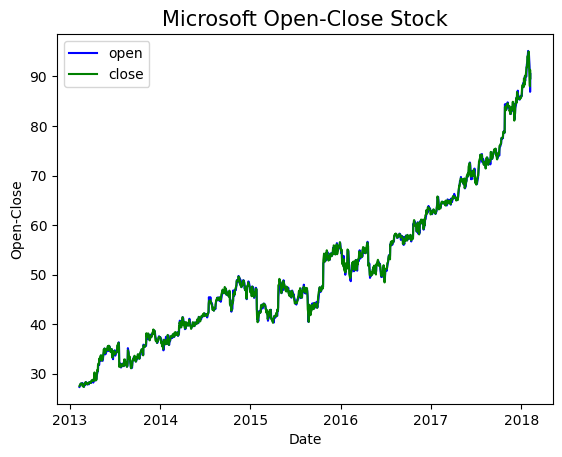

In [17]:
df['date'] = pd.to_datetime(df['date'])
plt.plot(df['date'], df['open'], c='b', label='open')
plt.plot(df['date'], df['close'], c='g', label='close')
plt.title('Microsoft Open-Close Stock', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Open-Close')
plt.legend()
plt.show()

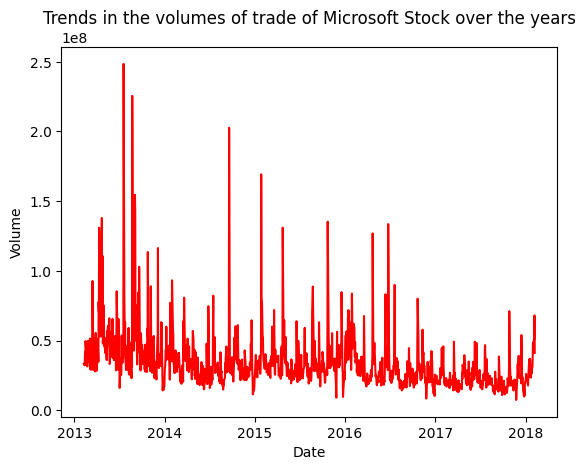

In [18]:
plt.plot(df['date'], df['volume'], c='r')
plt.title('Trends in the volumes of trade of Microsoft Stock over the years')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

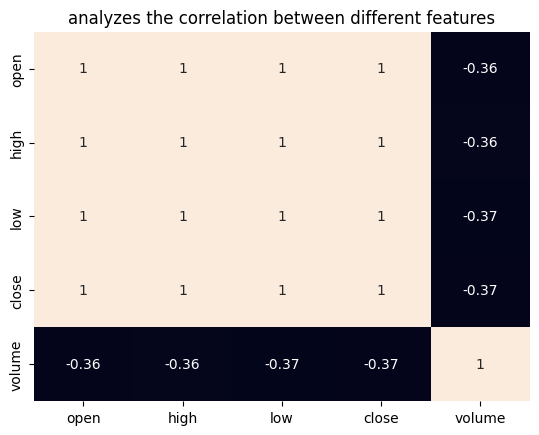

In [20]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cbar=False)
plt.title("analyzes the correlation between different features")
plt.show()

In [33]:
from datetime import datetime
prediction = df.loc[(df['date'] > datetime(2013,1,1)) & (df['date'] < datetime(2018,1,1))]
prediction

,date,open,high,low,close,volume,Name
0,2013-02-08,27.35,27.7100,27.310,27.55,33318306,MSFT
1,2013-02-11,27.65,27.9200,27.500,27.86,32247549,MSFT
2,2013-02-12,27.88,28.0000,27.750,27.88,35990829,MSFT
3,2013-02-13,27.93,28.1100,27.880,28.03,41715530,MSFT
4,2013-02-14,27.92,28.0600,27.870,28.04,32663174,MSFT
...,...,...,...,...,...,...,...
1228,2017-12-22,85.40,85.6300,84.920,85.51,14145841,MSFT
1229,2017-12-26,85.31,85.5346,85.030,85.40,9891237,MSFT
1230,2017-12-27,85.65,85.9800,85.215,85.71,14678025,MSFT
1231,2017-12-28,85.90,85.9300,85.550,85.72,10594344,MSFT


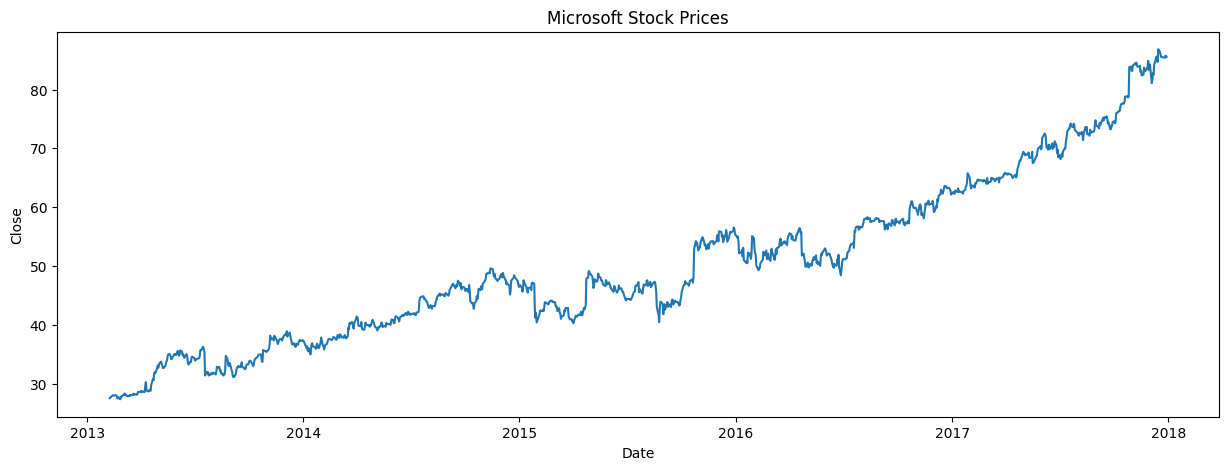

In [34]:

plt.figure(figsize=(15, 5))
plt.plot(prediction['date'], prediction['close'])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Microsoft Stock Prices")
plt.show()

In [58]:
# prepare the training set samples
msft_close = df.filter(['close'])
dataset = msft_close.values

X = []
y = []

# considering 60 as the window size
# create X and y
for i in range(60, len(dataset)):
    X.append(dataset[i-60:i, 0])
    y.append(dataset[i, 0])

# convert to numpy arrays for keras
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

2. Train Test Split

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3. Feature Scalling

In [60]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# scale 2D inputs (samples, timesteps)
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# reshape to 3D for LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ensure y is numpy array
y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

##### 4. Biuld the Model

In [61]:
import tensorflow as tf

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.LSTM(units=64,
                            return_sequences=True,
                            input_shape
                            =(X_train.shape[1], 1)))
model.add(tf.keras.layers.LSTM(units=64))
model.add(tf.keras.layers.Dense(128))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

##### 5. Compile and Fit the Model

In [62]:
model.compile(optimizer='adam', 
            loss='mae', 
            metrics=[tf.keras.metrics.RootMeanSquaredError()])

In [63]:
history = model.fit(X_train, y_train, 
					epochs=20,
                    validation_data = (X_test, y_test)) 

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 45.3686 - root_mean_squared_error: 48.4077 - val_loss: 25.4266 - val_root_mean_squared_error: 29.2805
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 14.7631 - root_mean_squared_error: 18.4813 - val_loss: 11.1701 - val_root_mean_squared_error: 14.3250
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 11.8589 - root_mean_squared_error: 15.2079 - val_loss: 10.9051 - val_root_mean_squared_error: 14.2371
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 11.2720 - root_mean_squared_error: 14.7737 - val_loss: 9.2839 - val_root_mean_squared_error: 12.6307
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 9.2492 - root_mean_squared_error: 12.0785 - val_loss: 7.1541 - val_root_mean_squared_error: 9.2632
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 7.7425 - root_mean_squared_error: 9.7750 - val_loss: 6.1299 - val_root_mean_squared_error: 8.3880
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 

##### 6. Evaluate the Model

Test MAE (loss): 1.0579
Test RMSE: 1.4969
Test R^2: 0.9890


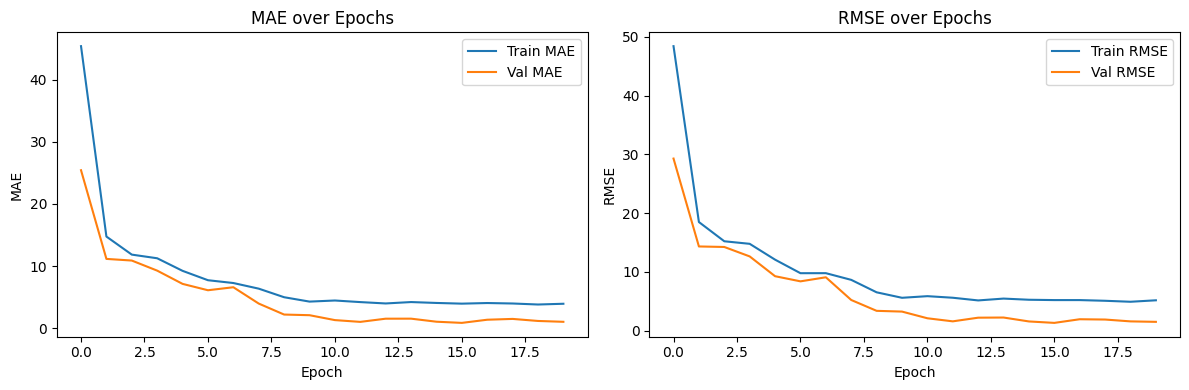

In [64]:
# Evaluate on test set
test_loss, test_rmse = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE (loss): {test_loss:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

# Optional: R^2 score
from sklearn.metrics import r2_score
y_pred_eval = model.predict(X_test, verbose=0).flatten()
r2 = r2_score(y_test, y_pred_eval)
print(f"Test R^2: {r2:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train MAE')
plt.plot(history.history['val_loss'], label='Val MAE')
plt.title('MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['root_mean_squared_error'], label='Train RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
plt.title('RMSE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.show()

##### 7. Make Predictions

In [65]:
# Predict on test set
y_pred = model.predict(X_test, verbose=0).flatten()

# Compare actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual': y_test.flatten(),
    'Predicted': y_pred
})
comparison_df.head(10)

,Actual,Predicted
0,88.279999,85.801537
1,58.040001,56.998844
2,33.279999,33.193027
3,41.599998,41.695484
4,31.850000,33.036999
5,72.690002,71.407974
6,45.110001,43.556820
7,64.870003,63.643219
8,47.980000,46.076336
9,94.260002,88.284477


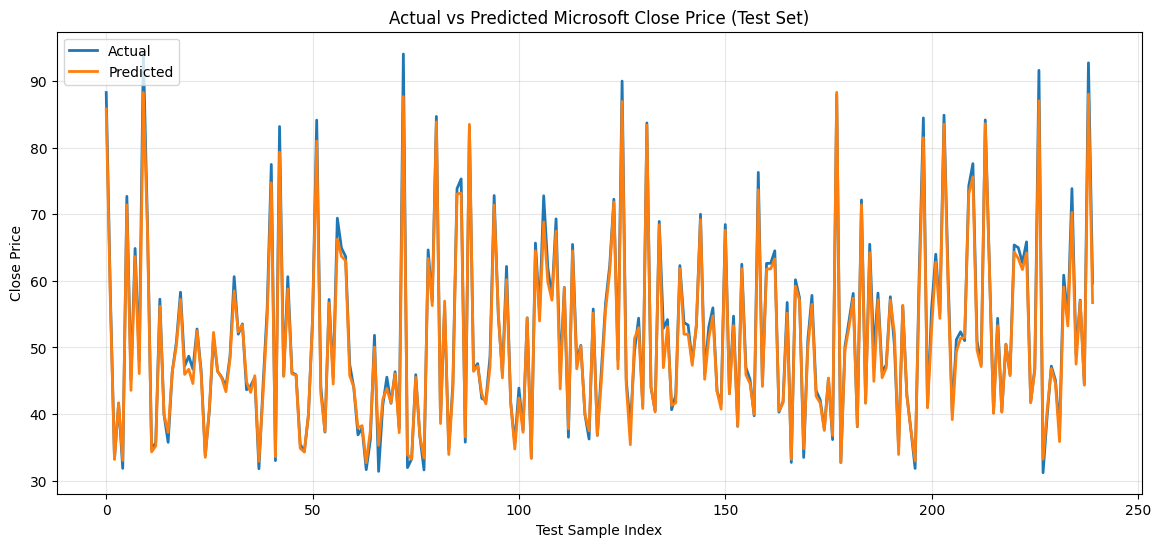

In [66]:
# Plot Actual vs Predicted (test set)
plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Actual', linewidth=2)
plt.plot(y_pred, label='Predicted', linewidth=2)
plt.title('Actual vs Predicted Microsoft Close Price (Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(alpha=0.3)
plt.show()